# Customer Propensity Modeling — Exploratory Data Analysis

## Objective

Analyze customer and campaign data to identify patterns associated with
subscription behavior and assess data quality before developing a
production-oriented propensity model.

### Key objectives

- Understand dataset structure and data quality
- Analyze the target variable and class imbalance
- Explore customer characteristics and behavioral patterns
- Identify potential data leakage
- Assess relationships between features and the target
- Define considerations for feature engineering and model development


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [2]:
df = pd.read_csv("../data/bank-full.csv", sep=";")

df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")


Number of rows: 45,211
Number of columns: 17


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [5]:
feature_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_values": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100).round(2),
    "unique_values": df.nunique()
})

feature_summary.sort_values(
    by="missing_pct",
    ascending=False
)


,dtype,missing_values,missing_pct,unique_values
age,int64,0,0.0,77
job,str,0,0.0,12
marital,str,0,0.0,3
education,str,0,0.0,4
default,str,0,0.0,2
balance,int64,0,0.0,7168
housing,str,0,0.0,2
loan,str,0,0.0,2
contact,str,0,0.0,3
day,int64,0,0.0,31


In [6]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0]


Series([], dtype: int64)

In [7]:
unknown_counts = {}

for column in df.select_dtypes(include=["str"]).columns:
    count = (df[column] == "unknown").sum()
    if count > 0:
        unknown_counts[column] = count

unknown_df = (
    pd.Series(unknown_counts, name="unknown_count")
      .sort_values(ascending=False)
)

unknown_df


poutcome     36959
contact      13020
education     1857
job            288
Name: unknown_count, dtype: int64

In [8]:
unknown_summary = pd.DataFrame({
    "unknown_count": unknown_df,
    "unknown_pct": (unknown_df / len(df) * 100).round(2)
})

unknown_summary


,unknown_count,unknown_pct
poutcome,36959,81.75
contact,13020,28.80
education,1857,4.11
job,288,0.64


In [9]:
df["poutcome"].value_counts(dropna=False)


poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [10]:
df["poutcome"].value_counts(normalize=True).mul(100).round(2)


poutcome
unknown    81.75
failure    10.84
other       4.07
success     3.34
Name: proportion, dtype: float64

In [11]:
target_counts = df["y"].value_counts()

target_pct = (
    df["y"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Counts:")
print(target_counts)

print("\nPercentage:")
print(target_pct)


Counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Percentage:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


In [12]:
conversion_rate = df["y"].eq("yes").mean()

print(f"Overall conversion rate: {conversion_rate:.2%}")


Overall conversion rate: 11.70%


In [13]:
poutcome_conversion = (
    df.groupby("poutcome")["y"]
      .apply(lambda x: x.eq("yes").mean())
      .sort_values(ascending=False)
      .mul(100)
      .round(2)
)

poutcome_conversion


poutcome
success    64.73
other      16.68
failure    12.61
unknown     9.16
Name: y, dtype: float64

In [14]:
df["poutcome"].value_counts()


poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [15]:
target_counts
target_pct


y
no     88.3
yes    11.7
Name: proportion, dtype: float64

In [16]:
poutcome_conversion


poutcome
success    64.73
other      16.68
failure    12.61
unknown     9.16
Name: y, dtype: float64

## Initial EDA Findings

### Target Distribution

The target variable is imbalanced, with 88.3% of observations corresponding
to non-subscription and 11.7% corresponding to subscription.

This indicates that accuracy alone would not be an appropriate primary metric
for evaluating the propensity model. Model evaluation should include ranking
and class-sensitive metrics such as ROC-AUC, PR-AUC, Precision@K, Recall,
and Lift.

### Previous Campaign Outcome

Previous campaign outcome shows a strong association with subscription behavior.

Customers with a previous successful campaign outcome have a substantially
higher observed subscription rate than customers with other recorded outcomes.

This feature will therefore be investigated as a potentially important
predictor during model development.

### Unknown Values

The `poutcome` feature contains a large proportion of `unknown` values.
Rather than treating these observations as conventional missing data, the
`unknown` category will be preserved initially because the absence of previous
campaign information may itself contain predictive information.


In [17]:
job_conversion = (
    df.groupby("job")["y"]
      .apply(lambda x: x.eq("yes").mean())
      .sort_values(ascending=False)
      .mul(100)
      .round(2)
)

job_conversion


job
student          28.68
retired          22.79
unemployed       15.50
management       13.76
admin.           12.20
self-employed    11.84
unknown          11.81
technician       11.06
services          8.88
housemaid         8.79
entrepreneur      8.27
blue-collar       7.27
Name: y, dtype: float64

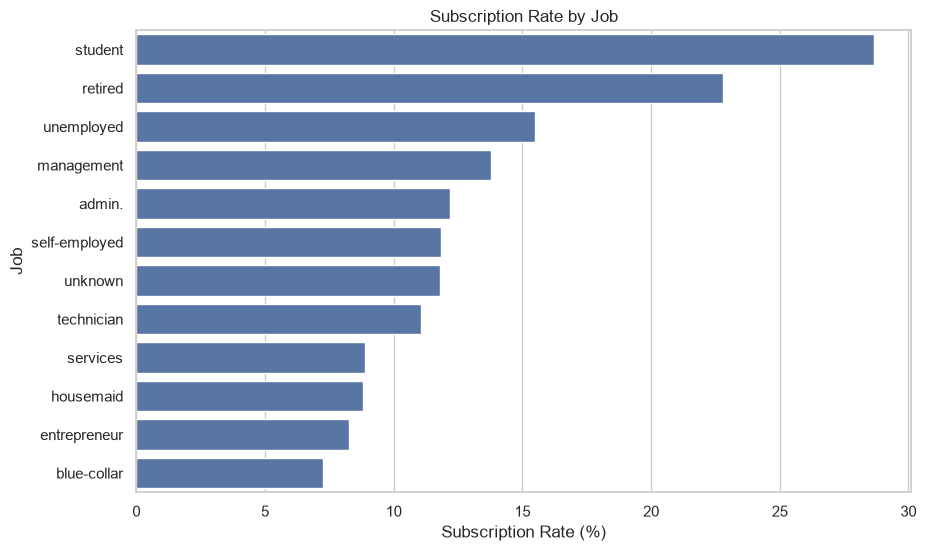

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=job_conversion.values,
    y=job_conversion.index
)

plt.title("Subscription Rate by Job")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")

plt.show()


In [19]:
education_conversion = (
    df.groupby("education")["y"]
      .apply(lambda x: x.eq("yes").mean())
      .sort_values(ascending=False)
      .mul(100)
      .round(2)
)

education_conversion


education
tertiary     15.01
unknown      13.57
secondary    10.56
primary       8.63
Name: y, dtype: float64

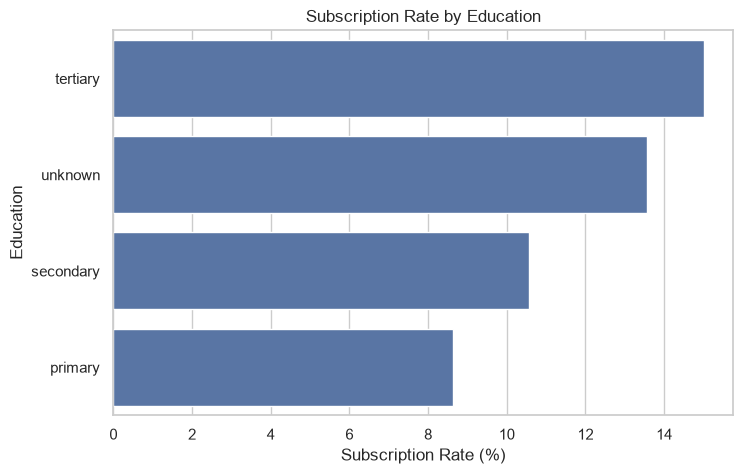

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=education_conversion.values,
    y=education_conversion.index
)

plt.title("Subscription Rate by Education")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Education")

plt.show()


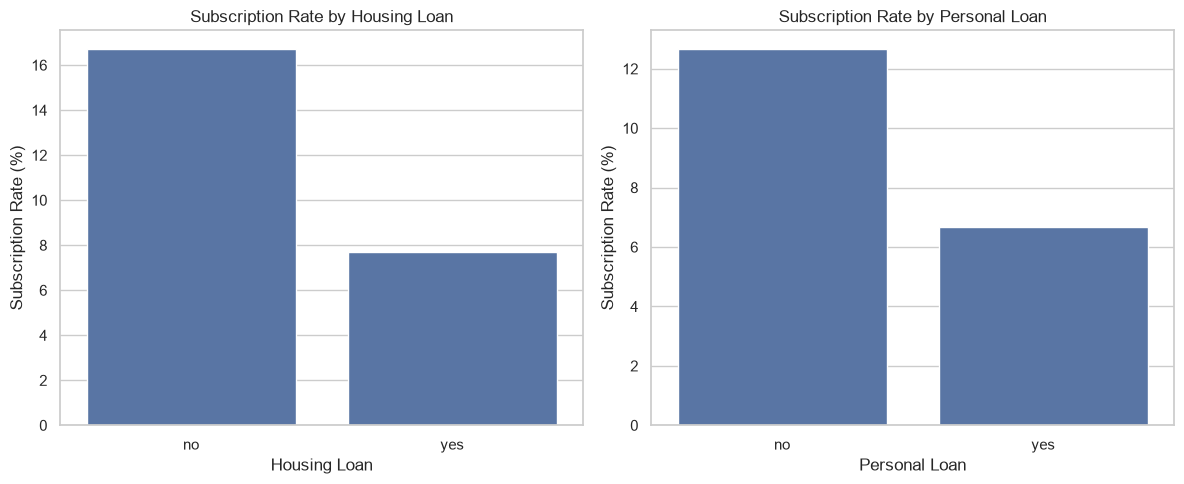

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

housing_rate = (
    df.groupby("housing")["y"]
      .apply(lambda x: x.eq("yes").mean())
      .mul(100)
)

loan_rate = (
    df.groupby("loan")["y"]
      .apply(lambda x: x.eq("yes").mean())
      .mul(100)
)

sns.barplot(
    x=housing_rate.index,
    y=housing_rate.values,
    ax=axes[0]
)

axes[0].set_title("Subscription Rate by Housing Loan")
axes[0].set_ylabel("Subscription Rate (%)")
axes[0].set_xlabel("Housing Loan")

sns.barplot(
    x=loan_rate.index,
    y=loan_rate.values,
    ax=axes[1]
)

axes[1].set_title("Subscription Rate by Personal Loan")
axes[1].set_ylabel("Subscription Rate (%)")
axes[1].set_xlabel("Personal Loan")

plt.tight_layout()
plt.show()


In [22]:
age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = [
    "<=25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)


In [23]:
age_conversion = (
    df.groupby("age_group", observed=True)["y"]
      .apply(lambda x: x.eq("yes").mean())
      .mul(100)
      .round(2)
)

age_conversion


age_group
<=25     23.95
26-35    12.00
36-45     9.39
46-55     9.35
56-65    14.12
66+      42.61
Name: y, dtype: float64

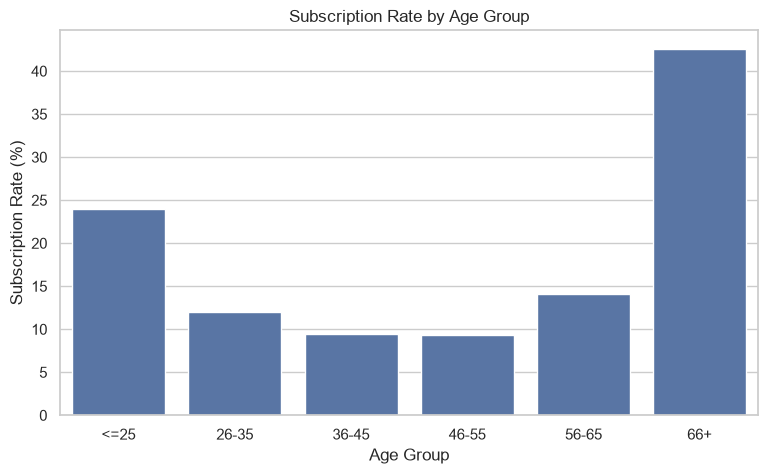

In [24]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=age_conversion.index,
    y=age_conversion.values
)

plt.title("Subscription Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Subscription Rate (%)")

plt.show()


In [25]:
age_counts = df["age_group"].value_counts().sort_index()

age_counts


age_group
<=25      1336
26-35    15571
36-45    13856
46-55     9548
56-65     4149
66+        751
Name: count, dtype: int64

In [26]:
age_summary = pd.DataFrame({
    "customer_count": age_counts,
    "subscription_rate": age_conversion
})

age_summary


,customer_count,subscription_rate
age_group,,
<=25,1336,23.95
26-35,15571,12.00
36-45,13856,9.39
46-55,9548,9.35
56-65,4149,14.12
66+,751,42.61


In [27]:
job_summary = pd.DataFrame({
    "customer_count": df["job"].value_counts(),
    "subscription_rate": job_conversion
}).sort_values(
    "subscription_rate",
    ascending=False
)

job_summary


,customer_count,subscription_rate
job,,
student,938,28.68
retired,2264,22.79
unemployed,1303,15.50
management,9458,13.76
admin.,5171,12.20
self-employed,1579,11.84
unknown,288,11.81
technician,7597,11.06
services,4154,8.88


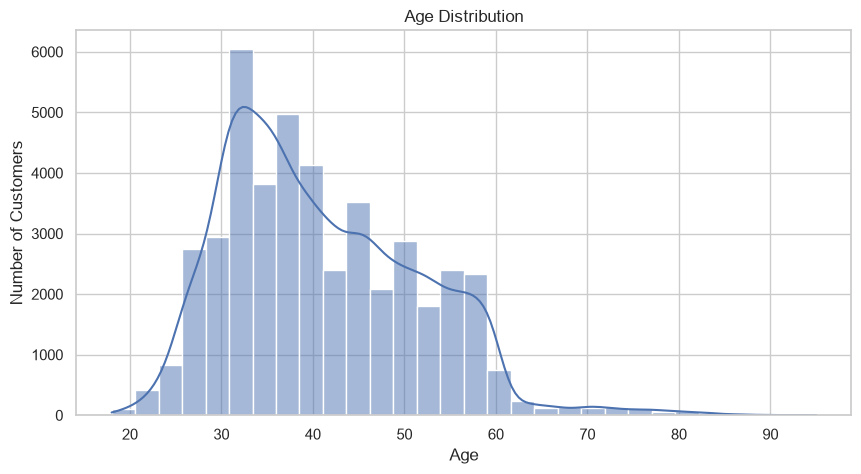

In [30]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()


In [29]:
df["age"].describe()


count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64

## Customer Demographic Findings

### Job

Observed subscription rates vary substantially across occupational groups.
This suggests that occupation may provide useful predictive information.
However, these are univariate associations and may reflect relationships
with other customer characteristics.

### Education

Subscription rates also vary across education categories. Education will
therefore be retained as a candidate predictor and evaluated alongside other
features during model development.

### Age

Subscription rates vary nonlinearly across age groups. The 66+ group has
a substantially higher observed subscription rate than the middle-aged
groups, while customers aged 25 or younger also show an elevated rate.

The relationship therefore does not appear to follow a simple monotonic
linear pattern. Age will be retained as a candidate predictor, with
nonlinear relationships considered during model development.



In [31]:
def category_response_summary(data, feature, target="y"):
    summary = (
        data.groupby(feature)[target]
        .agg(
            customer_count="size",
            subscribers=lambda x: x.eq("yes").sum()
        )
    )

    summary["subscription_rate"] = (
        summary["subscribers"]
        / summary["customer_count"]
        * 100
    ).round(2)

    return summary.sort_values(
        "subscription_rate",
        ascending=False
    )


In [32]:
category_response_summary(df, "job")


,customer_count,subscribers,subscription_rate
job,,,
student,938,269,28.68
retired,2264,516,22.79
unemployed,1303,202,15.50
management,9458,1301,13.76
admin.,5171,631,12.20
self-employed,1579,187,11.84
unknown,288,34,11.81
technician,7597,840,11.06
services,4154,369,8.88


In [33]:
category_response_summary(df, "education")


,customer_count,subscribers,subscription_rate
education,,,
tertiary,13301,1996,15.01
unknown,1857,252,13.57
secondary,23202,2450,10.56
primary,6851,591,8.63


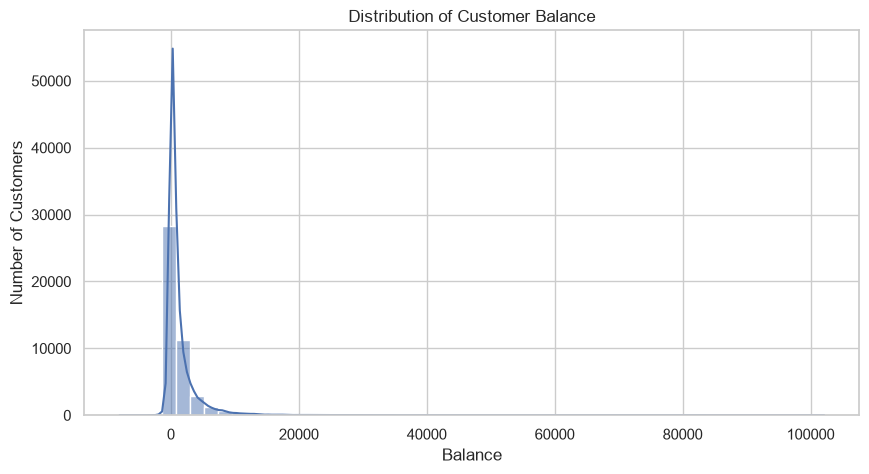

In [35]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="balance",
    bins=50,
    kde=True
)

plt.title("Distribution of Customer Balance")
plt.xlabel("Balance")
plt.ylabel("Number of Customers")

plt.show()



In [36]:
df["balance"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])


count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
1%         -627.000000
5%         -172.000000
25%          72.000000
50%         448.000000
75%        1428.000000
95%        5768.000000
99%       13164.900000
max      102127.000000
Name: balance, dtype: float64

In [39]:
print(
    "pdays = -1:",
    (df["pdays"] == -1).sum(),
    f"({(df['pdays'] == -1).mean():.2%})"
)


pdays = -1: 36954 (81.74%)


In [40]:
df.groupby("y")["duration"].describe()


,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,39922.0,221.182806,207.383237,0.0,95.0,164.0,279.0,4918.0
yes,5289.0,537.294574,392.525262,8.0,244.0,426.0,725.0,3881.0


In [41]:
pdays_contacted = df["pdays"].ne(-1)

pdays_summary = (
    df.assign(previously_contacted=pdays_contacted)
      .groupby("previously_contacted")["y"]
      .apply(lambda x: x.eq("yes").mean())
      .mul(100)
      .round(2)
)

pdays_summary


previously_contacted
False     9.16
True     23.07
Name: y, dtype: float64

In [42]:
previous_conversion = (
    df.groupby("previous")["y"]
      .apply(lambda x: x.eq("yes").mean())
      .mul(100)
      .round(2)
)

previous_conversion.head(20)


previous
0      9.16
1     21.03
2     21.65
3     25.74
4     23.95
5     26.36
6     29.96
7     26.34
8     30.23
9     26.09
10    38.81
11    23.08
12    22.73
13    23.68
14    26.32
15     5.00
16     0.00
17    20.00
18     0.00
19    18.18
Name: y, dtype: float64

In [43]:
pd.crosstab(
    df["pdays"] == -1,
    df["poutcome"] == "unknown"
)


poutcome,False,True
pdays,,
False,8252,5
True,0,36954


In [44]:
pdays_positive = df.loc[
    df["pdays"] != -1,
    "pdays"
]

pdays_positive.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)


count    8257.000000
mean      224.577692
std       115.344035
min         1.000000
1%          7.560000
5%         79.000000
25%       133.000000
50%       194.000000
75%       327.000000
95%       370.000000
99%       531.440000
max       871.000000
Name: pdays, dtype: float64

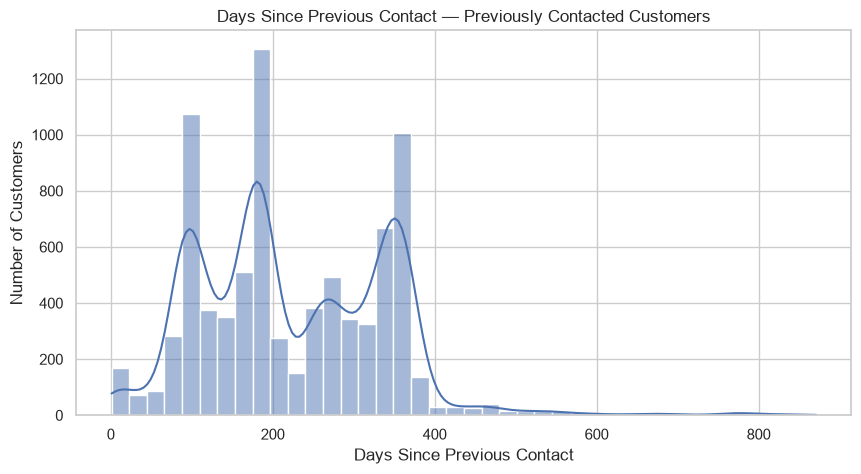

In [45]:
plt.figure(figsize=(10, 5))

sns.histplot(
    pdays_positive,
    bins=40,
    kde=True
)

plt.title("Days Since Previous Contact — Previously Contacted Customers")
plt.xlabel("Days Since Previous Contact")
plt.ylabel("Number of Customers")

plt.show()


In [46]:
poutcome_summary = (
    df.groupby("poutcome")["y"]
      .agg(
          customer_count="size",
          subscribers=lambda x: x.eq("yes").sum()
      )
)

poutcome_summary["subscription_rate"] = (
    poutcome_summary["subscribers"]
    / poutcome_summary["customer_count"]
    * 100
).round(2)

poutcome_summary


,customer_count,subscribers,subscription_rate
poutcome,,,
failure,4901,618,12.61
other,1840,307,16.68
success,1511,978,64.73
unknown,36959,3386,9.16


In [48]:
previous_summary = (
    df.groupby("previous")["y"]
      .agg(
          customer_count="size",
          subscribers=lambda x: x.eq("yes").sum()
      )
)

previous_summary["subscription_rate"] = (
    previous_summary["subscribers"]
    / previous_summary["customer_count"]
    * 100
).round(2)

previous_summary



,customer_count,subscribers,subscription_rate
previous,,,
0,36954,3384,9.16
1,2772,583,21.03
2,2106,456,21.65
3,1142,294,25.74
4,714,171,23.95
5,459,121,26.36
6,277,83,29.96
7,205,54,26.34
8,129,39,30.23


In [49]:
pdays_positive = df.loc[
    df["pdays"] != -1,
    "pdays"
]

pdays_positive.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)


count    8257.000000
mean      224.577692
std       115.344035
min         1.000000
1%          7.560000
5%         79.000000
25%       133.000000
50%       194.000000
75%       327.000000
95%       370.000000
99%       531.440000
max       871.000000
Name: pdays, dtype: float64

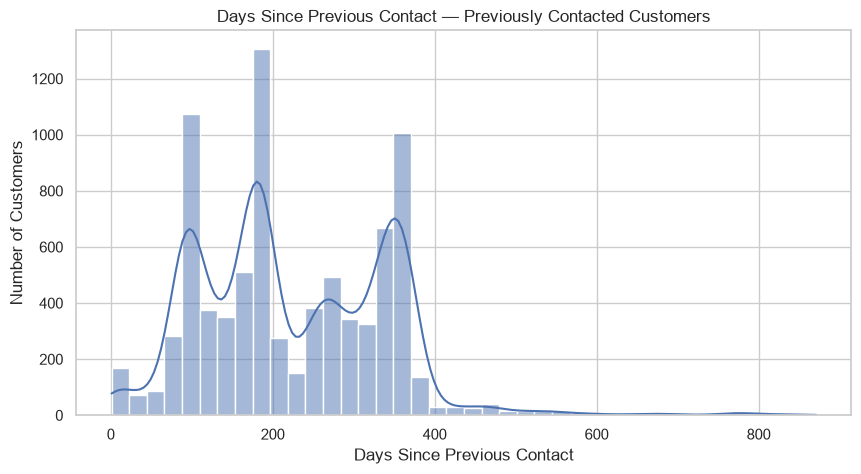

In [50]:
plt.figure(figsize=(10, 5))

sns.histplot(
    pdays_positive,
    bins=40,
    kde=True
)

plt.title(
    "Days Since Previous Contact — Previously Contacted Customers"
)
plt.xlabel("Days Since Previous Contact")
plt.ylabel("Number of Customers")

plt.show()


### Previous Contact Recency — `pdays`

Among customers with recorded previous contact, the median time since the
previous contact is 194 days, with substantial variation across customers.

The `pdays` variable has two distinct semantic states:

- `-1` indicates no previous contact.
- Positive values represent the number of days since the previous contact.

Because these states have different meanings, `pdays` will not be treated as
a conventional continuous variable without further consideration.

During feature engineering, previous-contact status and contact recency will
be evaluated as separate concepts.


In [51]:
target = "y"

features = [
    "age",
    "job",
    "marital",
    "education",
    "default",
    "balance",
    "housing",
    "loan",
    "contact",
    "pdays",
    "previous",
    "poutcome"
]

X = df[features].copy()
y = df[target].eq("yes").astype(int)

print(f"Features: {len(features)}")
print(f"Observations: {len(X):,}")
print(f"Positive class rate: {y.mean():.2%}")


Features: 12
Observations: 45,211
Positive class rate: 11.70%


In [52]:
"duration" in X.columns


False

In [53]:
"campaign" in X.columns


False

# EDA Findings & Modeling Implications

## Data Quality

- The dataset contains **45,211 observations and 17 variables**.
- No conventional null values were identified.
- Several categorical variables contain explicit `unknown` values, particularly `poutcome`.
- No fully duplicated records were identified.

## Target Variable

- The subscription rate is **11.7%**, indicating substantial class imbalance.
- Because the majority class represents 88.3% of observations, accuracy alone would not be an appropriate primary evaluation metric.
- Model evaluation should emphasize **ROC-AUC, PR-AUC, precision, recall, and customer-ranking metrics such as Precision@K and Lift@K**.

## Customer Characteristics

- Subscription rates vary substantially across occupational and education categories.
- Age shows a **nonlinear relationship** with observed subscription behavior, with higher rates among both younger and older customers.
- Customer balance is strongly right-skewed, with a substantial upper tail. Extreme values will not be removed automatically because they may represent valid customer observations.

## Historical Campaign Behavior

- Customers with previous campaign contact have a substantially higher observed subscription rate than customers without previous contact history (**23.07% vs. 9.16%**).
- Previous campaign outcome is strongly associated with the current subscription outcome, with customers whose previous campaign outcome was `success` showing a **64.73% observed subscription rate**.
- `pdays` uses `-1` to indicate no previous contact. Among previously contacted customers, the median time since contact is **194 days**, suggesting that contact recency may contain additional predictive information.
- `pdays`, `previous`, and `poutcome` contain overlapping information about historical campaign engagement and will be considered carefully during feature engineering.

## Leakage Considerations

- `duration` shows a strong relationship with the target, but it represents information generated during the current customer interaction.
- Because this project is designed for **pre-contact customer targeting**, `duration` would not be available when the propensity score is generated.
- `campaign` is also excluded from the initial model because it represents the number of contacts made during the current campaign.
- `day` and `month` will also be excluded from the initial pre-contact model because they describe the current campaign contact rather than stable customer information.

## Modeling Implications

The EDA suggests that the dataset contains meaningful predictive signal across customer demographics, financial characteristics, and historical campaign engagement.

The modeling phase will therefore focus on:

1. Building a leakage-safe preprocessing pipeline.
2. Establishing Logistic Regression as an interpretable baseline.
3. Comparing tree-based models such as Random Forest and XGBoost.
4. Evaluating performance using both discrimination and ranking metrics.
5. Assessing probability calibration because the model will produce customer propensity scores.
6. Comparing model performance against the **11.7% baseline subscription rate**.
